# Lesson 20: Naive Bayes text classification demo

This notebook uses a standard text dataset to show how to classify documents with a simple bag-of-words encoding and sklearn's naive Bayes classifier.

Dataset source: [20 newsgroups text dataset](https://scikit-learn.org/stable/datasets/real_world.html#the-20-newsgroups-text-dataset).

1. Introduction

2. Notebook set up

    - Imports
    - Load 3 classes from 20 newsgroups dataset

3. Clean the text.

    - Remove numbers, special characters and punctuation
    - Lowercase all characters

4. Encode text with word counts.

    - Use `CountVectorizer` as the simplest baseline representation.

5. Train and evaluate a naive Bayes model.

    - Fit `MultinomialNB` on the encoded text.
    - Inspect accuracy, a confusion matrix, and example predictions.

6. Results

    - Confusion matrix
    - Learned words
    - Predict new examples


## 1. Introduction

### 1.1. Bag-of-words

To use any type of model on text we first need to represent that text as numbers. We have seen methods to do this previously, such as one-hot-encoding, but these won't work here. We may have long stings of text and texts of different lengths. One of the simplest ways to 'vectorize' or turn text into numbers is to use word frequencies:

|text                  |
|----------------------|
|The food was good     |
|The food was awesome  |
|The food was terrible |

In this collection of documents, we have the following word counts:

```text
the: 3
food: 3
was: 3
good: 1
awesome: 1
terrible: 1
```

And those words can be used as features:

|text                  | the | food | was | good | awesome | terrible |
|----------------------|-----|------|-----|------|---------|----------|
|The food was good     | 1   | 1    | 1   | 1    | 0       | 0        |
|The food was awesome  | 1   | 1    | 1   | 0    | 1       | 0        |
|The food was terrible | 1   | 1    | 1   | 0    | 0       | 1        |

This type of analysis is known as bag-of-words because it throws all of the words together, jumbles them up and only looks at their frequencies.


### 1.2. Naive bayes

The naive bayes model learns the probability of the label based on it's co-occurrence with the features in the training set. Let's add a label to our toy data:

|text                  | the | food | was | good | awesome | terrible | review sentiment |
|----------------------|-----|------|-----|------|---------|----------|------------------|
|The food was good     | 1   | 1    | 1   | 1    | 0       | 0        | positive         |
|The food was awesome  | 1   | 1    | 1   | 0    | 1       | 0        | positive         |
|The food was terrible | 1   | 1    | 1   | 0    | 0       | 1        | negative         |


The probability that a review is negative in the test set is 33% (1/3). While the probability that a review is negative given that it contains the word bad is 100% (1/1)! Obviously real data is not this simple, but this example demonstrates a how the naive bayes model can 'learn' from data.

## 2. Notebook set up

### 2.1. Imports

In [1]:
# Standard library imports
import re

# Third party imports
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.naive_bayes import MultinomialNB

### 2.2. Load the dataset

In [2]:
# Choose three familiar categories so the example stays readable
categories = ['rec.autos', 'sci.med', 'talk.politics.misc']

train_data = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
)

test_data = fetch_20newsgroups(
    subset='test',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
)

label_names = train_data.target_names
label_map = dict(enumerate(label_names))

train_df = pd.DataFrame({'text': train_data.data, 'target': train_data.target})
test_df = pd.DataFrame({'text': test_data.data, 'target': test_data.target})

train_df['label'] = train_df['target'].map(label_map)
test_df['label'] = test_df['target'].map(label_map)

train_df.head()

,text,target,label
0,I want to get a car alarm and I am thinking ab...,0,rec.autos
1,I did hear this question asked during a radio ...,2,talk.politics.misc
2,Quoting Jeffrey J. Nucciarone's (nucci@microwa...,0,rec.autos
3,I can not believe the way this thread on candi...,1,sci.med
4,"\n\n\n\n\nOK, I admit I have no hard data on t...",2,talk.politics.misc


In [3]:
train_df['label'].value_counts()

label
rec.autos             594
sci.med               594
talk.politics.misc    465
Name: count, dtype: int64

## 3. Basic text preprocessing

Lowercase all text and remove numbers, punctuation, and other non-letter characters before encoding.

In [4]:
def clean_text(text):
    '''Removes non-alphabetic characters. Converts to lowercase.'''

    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

train_df[['text', 'clean_text']].head(3)

,text,clean_text
0,I want to get a car alarm and I am thinking ab...,i want to get a car alarm and i am thinking ab...
1,I did hear this question asked during a radio ...,i did hear this question asked during a radio ...
2,Quoting Jeffrey J. Nucciarone's (nucci@microwa...,quoting jeffrey j nucciarone s nucci microwave...


## 4. Encode text with word counts

`CountVectorizer` turns each document into a vector of word counts, which is the simplest bag-of-words representation.

In [5]:
vectorizer = CountVectorizer()

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

print(f'Training data shape: {X_train.shape}')

Training data shape: (1653, 20919)


In [6]:
features = pd.Series(vectorizer.get_feature_names_out(), name='sample vocabulary')
print(f'Num encoded features: {len(features)}')
features[10000:10020]

Num encoded features: 20919


10000      kaminski
10001         kampf
10002          kane
10003       kaneohe
10004        kangas
10005        kantor
10006        kaplan
10007      karadzic
10008         karel
10009          kari
10010       karicha
10011          karl
10012          karp
10013    kartagener
10014       karting
10015       kashina
10016         kasif
10017         kaski
10018        kaspar
10019         kathi
Name: sample vocabulary, dtype: str

## 5. Train the classifier

Multinomial naive Bayes is a simple probabilistic classifier that works well with word-count features, making it a strong baseline for text classification.

In [7]:
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train, train_df['target'])

predictions = naive_bayes.predict(X_test)

accuracy = accuracy_score(test_df['target'], predictions)
print(f'Test accuracy: {accuracy:.3f}')

Test accuracy: 0.886


## 6. Results

### 6.1. Confusion matrix

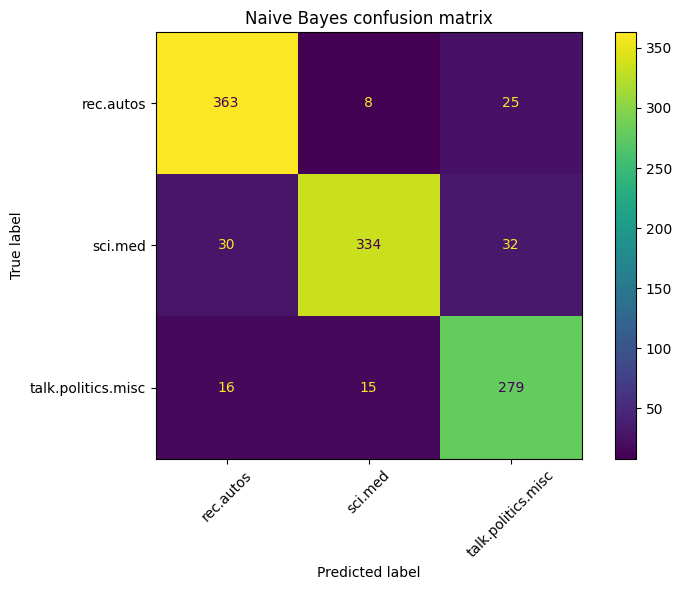

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    test_df['target'],
    predictions,
    display_labels=label_names,
    xticks_rotation=45,
    ax=ax
)

plt.title('Naive Bayes confusion matrix')
plt.tight_layout()
plt.show()

### 6.2. Inspect the learned words

Naive Bayes makes it easy to inspect which words are most associated with each class.

In [9]:
feature_names = vectorizer.get_feature_names_out()
top_n = 10

top_words = {}

for class_index, class_name in enumerate(label_names):
    top_indices = naive_bayes.feature_log_prob_[class_index].argsort()[-top_n:][::-1]
    top_words[class_name] = feature_names[top_indices]

pd.DataFrame(top_words)

,rec.autos,sci.med,talk.politics.misc
0,the,the,the
1,to,of,to
2,and,to,of
3,of,and,and
4,in,in,that
5,is,is,in
6,it,that,is
7,that,it,it
8,you,for,you
9,for,you,for


### 6.3. Predict new examples

In [10]:
sample_texts = [
    'My car needs new brakes and the engine is making a strange noise.',
    'The doctor recommended rest, hydration, and a follow-up appointment.',
    'The city council held a debate about taxes and public policy.',
]

sample_texts_clean = [clean_text(text) for text in sample_texts]

sample_counts = vectorizer.transform(sample_texts_clean)
sample_predictions = naive_bayes.predict(sample_counts)
sample_probabilities = naive_bayes.predict_proba(sample_counts)

prediction_df = pd.DataFrame({
    'text': sample_texts,
    'clean_text': sample_texts_clean,
    'predicted_label': [label_names[index] for index in sample_predictions],
    'confidence': sample_probabilities.max(axis=1).round(3),
})

prediction_df

,text,clean_text,predicted_label,confidence
0,My car needs new brakes and the engine is maki...,my car needs new brakes and the engine is maki...,rec.autos,1.000
1,"The doctor recommended rest, hydration, and a ...",the doctor recommended rest hydration and a fo...,sci.med,0.951
2,The city council held a debate about taxes and...,the city council held a debate about taxes and...,talk.politics.misc,1.000
